In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,classification_report
import seaborn as sns

In [15]:
#generate synthetic data for decision tree
np.random.seed(42)

#Class 0: not buy(e.g,yonger,lower income)
X_dt0 = np.random.normal(loc=[30, 40000], scale=[8,10000], size=(60, 2))
y_dt0= np.zeros(60)

#class 1: buy(e.g,older,higher income)
X_dt1 = np.random.normal(loc=[50, 70000],scale=[10, 15000],size=(60, 2))
y_dt1 = np.ones(60)

#combine data
X_dt = np.vstack((X_dt0, X_dt1))
y_dt = np.hstack((y_dt0, y_dt1))

df_dt=pd.DataFrame(X_dt, columns=["Age","Income"])
df_dt["Decision"]= y_dt
display(df_dt.head())



,Age,Income,Decision
0,33.973713,38617.356988,0.0
1,35.181508,55230.298564,0.0
2,28.126773,37658.630431,0.0
3,42.633703,47674.347292,0.0
4,26.244205,45425.600436,0.0


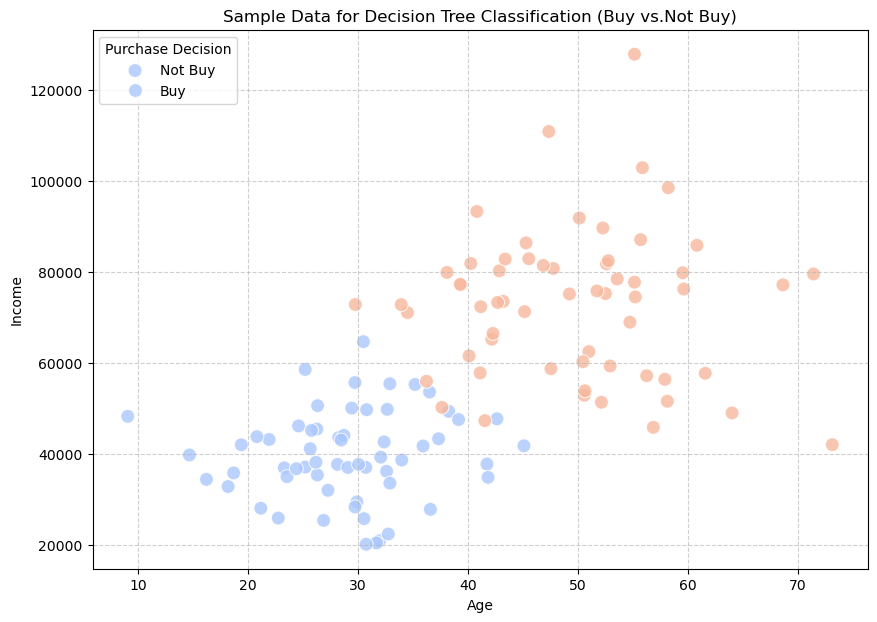

In [16]:
#plot the generated data for dcision tree
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Age',y='Income', hue='Decision', data=df_dt, palette='coolwarm', s=100, alpha=0.8)
plt.title('Sample Data for Decision Tree Classification (Buy vs.Not Buy)')
plt.xlabel('Age')
plt.ylabel('Income')
plt.grid(True, linestyle='--',alpha=0.6)
plt.legend(title='Purchase Decision', loc='upper left',labels=['Not Buy', 'Buy'])
plt.show()


In [17]:
X_dt_train, X_dt_test, y_dt_train, y_dt_test = train_test_split(X_dt, y_dt, test_size=0.3, random_state=42)

print(f"Training set shape for DT: {X_dt_train.shape}, {y_dt_train.shape}")
print(f"Testing set shape for DT:{X_dt_test.shape}, {y_dt_test.shape}")

Training set shape for DT: (84, 2), (84,)
Testing set shape for DT:(36, 2), (36,)


In [19]:
dt_classifier = DecisionTreeClassifier (max_depth=3, random_state=42)

dt_classifier.fit(X_dt_train, y_dt_train)

print("Decision Tree classifier trained successfully.")

Decision Tree classifier trained successfully.


In [20]:
y_dt_pred = dt_classifier.predict(X_dt_test)

print("First 10 actual labels for DT:", y_dt_test[:10])
print("First 10 predicted labels for DT:",y_dt_pred[:10])

First 10 actual labels for DT: [0. 0. 0. 0. 0. 1. 1. 0. 0. 1.]
First 10 predicted labels for DT: [0. 0. 0. 0. 0. 1. 0. 0. 0. 1.]


In [ ]:
dt_accuracy = accuracy_score(y_dt_test, y_dt_pred)
dt_report = classification_report(y_dt_test, y_dt_pred)

print(f"Decision Tree Accuracy: {dt_accuracy:.2f}")
print("Decision Tree Classification Report:\n", dt_report